# Import modules

In [9]:
import os
import sys

project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.append(project_root)

from src.pipeline2.Helper import (
    create_preprocessing_pipeline,
    load_and_split_data,
    preprocess_training_data,
    scale_and_handle_outliers,
    preprocess_test_data,
    evaluate_model, 
    save_model_and_pipeline,
    predict_new_data,
)

# Preparation

In [7]:
# 1. Load and split data T
train_data, test_data = load_and_split_data()

# 2. Create pipeline
pipeline = create_preprocessing_pipeline()

# 3. Fit pipeline on train data only
X_train, y_train, missing_fill_strategy = preprocess_training_data(train_data, pipeline)

# 4. Scale based on training data
X_train_scaled, scaler, bounds, numeric_features = scale_and_handle_outliers(X_train)

# 5. Apply fitted pipeline and scaler to test data
X_test_scaled, y_test = preprocess_test_data(
    test_data,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    missing_fill_strategy=missing_fill_strategy,
)

LOADING AND SPLITTING DATA


d:\Study\VPBank_Hackathon_25\src\pipeline2\Helper.py:82: DtypeWarning: Columns (26) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv(data_path)


Raw data loaded: (100000, 28)
After dropping personal info: (100000, 21)
Train data: (80000, 21)
Test data: (20000, 21)

PREPROCESSING TRAINING DATA
Training data after pipeline: (80000, 37)
Handling negative values...
Total negative values converted: 0
Handling missing values with intelligent strategy...
  Monthly_Inhand_Salary: 12032 missing -> median (3191104166666666.0000) (skewed: 2.60)
  Num_of_Delayed_Payment: 5595 missing -> median (14.0000) (skewed: 14.21)
  Changed_Credit_Limit: 1691 missing -> median (902.0000) (skewed: 10.44)
  Num_Credit_Inquiries: 1549 missing -> median (60.0000) (skewed: 9.69)
  Credit_History_Age: 7240 missing -> mean (18.4345) (normal dist)
  Amount_invested_monthly: 3605 missing -> median (8131127094677352.0000) (skewed: 1.77)
  Monthly_Balance: 950 missing -> median (6580492431588418.0000) (skewed: 106.26)
Converting object columns to numeric...
Training features: (80000, 36)
Training target distribution: {0: 14262, 1: 23199, 2: 42539}

SCALING AND O

c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\sklearn\pipeline.py:61: FutureWarning: This Pipeline instance is not fitted yet. Call 'fit' with appropriate arguments before using other methods such as transform, predict, etc. This will raise an error in 1.8 instead of the current warning.
  warnings.warn(


# XGBoost


TRAINING XGBOOST MODEL
Training XGBoost...
Training completed!

MODEL EVALUATION
Test Accuracy: 0.7915

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.72      0.74      3566
           1       0.79      0.79      0.79      5799
           2       0.80      0.82      0.81     10635

    accuracy                           0.79     20000
   macro avg       0.78      0.78      0.78     20000
weighted avg       0.79      0.79      0.79     20000



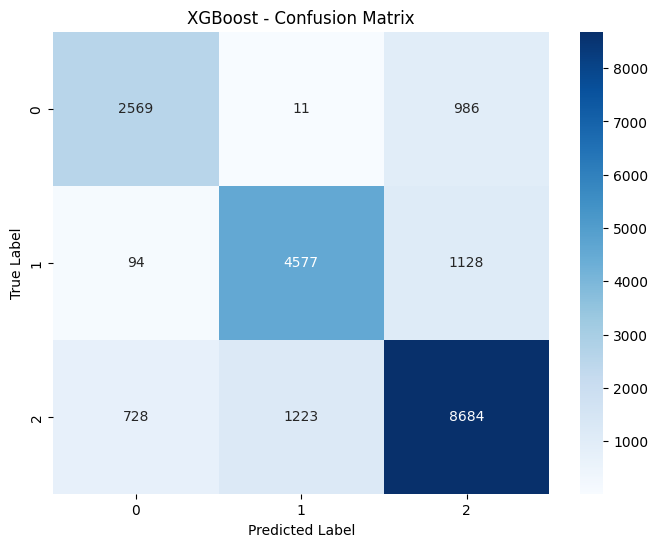


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\xgboost_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\xgboost.pkl
Scaler saved to: ..\models\xgboost_scaler.pkl
Model info saved to: ..\models\xgboost_info.pkl


In [3]:
from src.pipeline2.XGBoost import train_xgboost_model

model = train_xgboost_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="xgboost",
)

# Random Forest


TRAINING RANDOM FOREST MODEL
Training Random Forest...
Training completed!

MODEL EVALUATION
Test Accuracy: 0.7136

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.82      0.64      3566
           1       0.71      0.80      0.75      5799
           2       0.86      0.63      0.73     10635

    accuracy                           0.71     20000
   macro avg       0.70      0.75      0.70     20000
weighted avg       0.76      0.71      0.72     20000



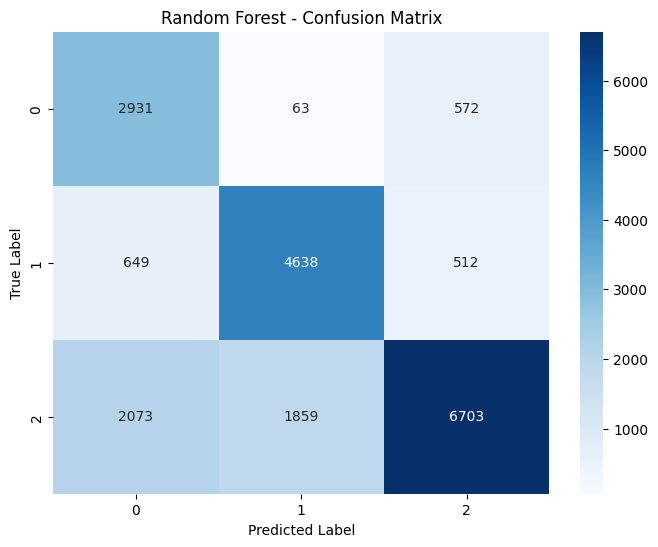


SAVING MODEL AND COMPONENTS
Preprocessing pipeline saved to: ..\models\randomforest_preprocessing_pipeline.pkl
XGBoost model saved to: ..\models\randomforest.pkl
Scaler saved to: ..\models\randomforest_scaler.pkl
Model info saved to: ..\models\randomforest_info.pkl


In [4]:
from src.pipeline2.RandomForest import train_randomforest_model

model = train_randomforest_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="randomforest",
)


# TabNet

In [5]:
from src.pipeline2.TabNet import train_tabnet_model

model = train_tabnet_model(X_train, y_train)

accuracy = evaluate_model(model, X_test_scaled, y_test)

model_path, pipeline_path, scaler_path, info_path = save_model_and_pipeline(
    model,
    pipeline,
    scaler,
    bounds,
    numeric_features,
    importance_df=None,
    accuracy=accuracy,
    missing_fill_strategy=missing_fill_strategy,
    model_name="tabnet",
)


TRAINING TABNET MODEL
Train split: (64000, 36)
Validation split: (16000, 36)
Training TabNet...


c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


TypeError: TabModel.fit() got an unexpected keyword argument 'early_stopping'

# Ensemble

In [11]:
# Load Pre-trained Models for Ensemble
import joblib

# TabNet imports
from pytorch_tabnet.tab_model import TabNetClassifier

print("=" * 80)
print("LOADING PRE-TRAINED MODELS FOR ENSEMBLE")
print("=" * 80)

# Define models directory
models_dir = "../models"

# Initialize storage for loaded models
loaded_models = {}
loaded_accuracies = {}
model_info = {}

def load_model_safely(model_name, model_type="sklearn"):
    """Safely load a model and its components"""
    try:
        if model_type == "tabnet":
            model_path = os.path.join(models_dir, f"{model_name}.zip") 
        else:
            model_path = os.path.join(models_dir, f"{model_name}.pkl")
        info_path = os.path.join(models_dir, f"{model_name}_info.pkl")
        
        if model_type == "tabnet":
            model = TabNetClassifier()
            model.load_model(model_path)
                
        else:
            print(f"🔄 Loading model from: {model_path}")
            model = joblib.load(model_path)
        
        # Load model info
        if os.path.exists(info_path):
            info = joblib.load(info_path)
            accuracy = info.get('accuracy', 0.0)
        else:
            accuracy = 0.0
            info = {}
            
        print(f"✅ {model_name} loaded")
        print(f"Test Accuracy: {accuracy:.4f}")
        return model, accuracy, info
        
    except Exception as e:
        print(f"❌ Failed to load {model_name}: {e}")
        return None, None, None

# Load XGBoost
print("\n🔄 Loading XGBoost model...")
model_xgb, accuracy_xgb, info_xgb = load_model_safely("xgboost")
if model_xgb is not None:
    loaded_models['XGBoost'] = model_xgb
    loaded_accuracies['XGBoost'] = accuracy_xgb
    model_info['XGBoost'] = info_xgb

# Load Random Forest
print("\n🔄 Loading Random Forest model...")
model_rf, accuracy_rf, info_rf = load_model_safely("randomforest")
if model_rf is not None:
    loaded_models['Random Forest'] = model_rf
    loaded_accuracies['Random Forest'] = accuracy_rf
    model_info['Random Forest'] = info_rf

# Load TabNet
print("\n🔄 Loading TabNet model...")
model_tabnet, accuracy_tabnet, info_tabnet = load_model_safely("tabnet", "tabnet")
if model_tabnet is not None:
    loaded_models['TabNet'] = model_tabnet
    loaded_accuracies['TabNet'] = accuracy_tabnet
    model_info['TabNet'] = info_tabnet
    
print(loaded_accuracies)

print(f"\n📊 SUMMARY:")
print(f"Successfully loaded {len(loaded_models)} models")

if len(loaded_models) >= 2:
    print(f"\n🚀 Ready to create ensemble with {len(loaded_models)} models!")
else:
    print(f"\n⚠️  Only {len(loaded_models)} model(s) loaded. Need at least 2 for ensemble.")

LOADING PRE-TRAINED MODELS FOR ENSEMBLE

🔄 Loading XGBoost model...
🔄 Loading model from: ../models\xgboost.pkl
✅ xgboost loaded
❌ Failed to load xgboost: unsupported format string passed to tuple.__format__

🔄 Loading Random Forest model...
🔄 Loading model from: ../models\randomforest.pkl
✅ randomforest loaded
❌ Failed to load randomforest: unsupported format string passed to tuple.__format__

🔄 Loading TabNet model...


c:\Users\PC\miniconda3\envs\vpbank\Lib\site-packages\pytorch_tabnet\abstract_model.py:82: UserWarning: Device used : cpu
  warnings.warn(f"Device used : {self.device}")


✅ tabnet loaded
❌ Failed to load tabnet: unsupported format string passed to tuple.__format__
{}

📊 SUMMARY:
Successfully loaded 0 models

⚠️  Only 0 model(s) loaded. Need at least 2 for ensemble.
